# Day 06 — Document Loaders & Text Splitting (hands-on)

Companion notebook to [`../notes.md`](../notes.md). Two parts:

- **Part 1 — the simple version.** Load a small text file, compare **fixed-size** vs **recursive** splitting, and see chunk overlap in real output. Fully offline.
- **Part 2 — a real PDF, step by step.** Seven small steps on a real 58-page research paper: page numbers, chunks, pictures, tables, scanned pages (OCR), and broken files.

No API key needed for either part. Part 2 downloads one public PDF (~4.7 MB) the first time it runs, into a git-ignored folder.

In [1]:
from pathlib import Path

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter

DATA_PATH = Path("data/sample_article.txt")

C:\Users\ramu\AppData\Local\Temp\ipykernel_32356\1896677247.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


C:\Users\ramu\OneDrive\Desktop\Agentic-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the document

A document loader turns a raw file into LangChain `Document` objects — each with `page_content` (the
text) and `metadata` (like where it came from). This is the same shape no matter what loader you use
(PDF, DOCX, webpage) — see `notes.md` Section 1.

In [2]:
loader = TextLoader(str(DATA_PATH), encoding="utf-8")
docs = loader.load()

print(f"Loaded {len(docs)} document(s)")
print("Metadata:", docs[0].metadata)
print("Total characters:", len(docs[0].page_content))
print()
print(docs[0].page_content)

Loaded 1 document(s)
Metadata: {'source': 'data\\sample_article.txt'}
Total characters: 886

Paris is the capital of France. It is known for the Eiffel Tower, which was completed in 1889 and stands about 330 meters tall. Millions of tourists visit every year to see its museums, architecture, and cafes along the Seine.

The Louvre Museum, located in the heart of Paris, is the world's largest art museum. It houses the Mona Lisa, painted by Leonardo da Vinci, along with thousands of other works spanning centuries of human history.

France has a temperate climate with warm summers and mild winters. Agriculture remains important to the French economy, particularly wine production in regions like Bordeaux and Burgundy, which are famous worldwide for their vineyards.

Paris is also a major center for fashion and cuisine. Many of the world's leading fashion houses were founded there, and French cooking techniques form the basis of much of modern Western culinary training.



## 2. Fixed-size splitting — cuts wherever the character count lands

`CharacterTextSplitter` with an empty separator just cuts every N characters, no matter what's there.
Watch the start/end of these chunks — they cut mid-word.

In [3]:
fixed_splitter = CharacterTextSplitter(separator="", chunk_size=120, chunk_overlap=0)
fixed_chunks = fixed_splitter.split_text(docs[0].page_content)

print(f"{len(fixed_chunks)} chunks\n")
for i, chunk in enumerate(fixed_chunks):
    print(f"--- chunk {i} ({len(chunk)} chars) ---")
    print(chunk)
    print()

8 chunks

--- chunk 0 (120 chars) ---
Paris is the capital of France. It is known for the Eiffel Tower, which was completed in 1889 and stands about 330 meter

--- chunk 1 (120 chars) ---
s tall. Millions of tourists visit every year to see its museums, architecture, and cafes along the Seine.

The Louvre M

--- chunk 2 (120 chars) ---
useum, located in the heart of Paris, is the world's largest art museum. It houses the Mona Lisa, painted by Leonardo da

--- chunk 3 (119 chars) ---
Vinci, along with thousands of other works spanning centuries of human history.

France has a temperate climate with wa

--- chunk 4 (120 chars) ---
rm summers and mild winters. Agriculture remains important to the French economy, particularly wine production in region

--- chunk 5 (119 chars) ---
s like Bordeaux and Burgundy, which are famous worldwide for their vineyards.

Paris is also a major center for fashion

--- chunk 6 (120 chars) ---
and cuisine. Many of the world's leading fashion houses were fou

Notice chunk 0 above ends mid-word (something like `...stands about 330 meter`) and the next chunk
picks up wherever the character count happened to land — not at a word or sentence boundary. This is
exactly the "cuts mid-word" problem from `notes.md` Section 2.

## 3. Recursive splitting — tries natural boundaries first

`RecursiveCharacterTextSplitter` tries paragraph breaks, then sentence breaks, then word breaks, before
resorting to a hard cut. Same source text, same `chunk_size`, much more readable chunks.

In [4]:
recursive_splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=20)
recursive_chunks = recursive_splitter.split_text(docs[0].page_content)

print(f"{len(recursive_chunks)} chunks\n")
for i, chunk in enumerate(recursive_chunks):
    print(f"--- chunk {i} ({len(chunk)} chars) ---")
    print(chunk)
    print()

10 chunks

--- chunk 0 (114 chars) ---
Paris is the capital of France. It is known for the Eiffel Tower, which was completed in 1889 and stands about 330

--- chunk 1 (117 chars) ---
stands about 330 meters tall. Millions of tourists visit every year to see its museums, architecture, and cafes along

--- chunk 2 (26 chars) ---
and cafes along the Seine.

--- chunk 3 (117 chars) ---
The Louvre Museum, located in the heart of Paris, is the world's largest art museum. It houses the Mona Lisa, painted

--- chunk 4 (113 chars) ---
Mona Lisa, painted by Leonardo da Vinci, along with thousands of other works spanning centuries of human history.

--- chunk 5 (119 chars) ---
France has a temperate climate with warm summers and mild winters. Agriculture remains important to the French economy,

--- chunk 6 (118 chars) ---
the French economy, particularly wine production in regions like Bordeaux and Burgundy, which are famous worldwide for

--- chunk 7 (30 chars) ---
worldwide for their vineyards

## 4. Seeing chunk overlap in real output

`chunk_overlap=20` means each chunk repeats a little of the previous chunk's ending. Let's print the
tail of chunk 0 next to the head of chunk 1 to see the shared text directly.

In [5]:
print("End of chunk 0:  ", repr(recursive_chunks[0][-35:]))
print("Start of chunk 1: ", repr(recursive_chunks[1][:35]))
print()
print("That overlap is exactly what protects a sentence sitting right at a chunk boundary")
print("from being lost — it still appears whole in at least one of the two chunks.")

End of chunk 0:   'pleted in 1889 and stands about 330'
Start of chunk 1:  'stands about 330 meters tall. Milli'

That overlap is exactly what protects a sentence sitting right at a chunk boundary
from being lost — it still appears whole in at least one of the two chunks.


## 5. A cleaner view: chunk size matched to paragraph length

If `chunk_size` comfortably fits a whole paragraph, recursive splitting aligns almost perfectly to
paragraph boundaries — no mid-sentence cuts at all.

In [6]:
clean_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=40)
clean_chunks = clean_splitter.split_text(docs[0].page_content)

print(f"{len(clean_chunks)} chunks\n")
for i, chunk in enumerate(clean_chunks):
    print(f"--- chunk {i} ({len(chunk)} chars) ---")
    print(chunk)
    print()

4 chunks

--- chunk 0 (226 chars) ---
Paris is the capital of France. It is known for the Eiffel Tower, which was completed in 1889 and stands about 330 meters tall. Millions of tourists visit every year to see its museums, architecture, and cafes along the Seine.

--- chunk 1 (212 chars) ---
The Louvre Museum, located in the heart of Paris, is the world's largest art museum. It houses the Mona Lisa, painted by Leonardo da Vinci, along with thousands of other works spanning centuries of human history.

--- chunk 2 (235 chars) ---
France has a temperate climate with warm summers and mild winters. Agriculture remains important to the French economy, particularly wine production in regions like Bordeaux and Burgundy, which are famous worldwide for their vineyards.

--- chunk 3 (206 chars) ---
Paris is also a major center for fashion and cuisine. Many of the world's leading fashion houses were founded there, and French cooking techniques form the basis of much of modern Western culinary tr

## Try it yourself

- Change `chunk_size` and `chunk_overlap` above and re-run — watch how the chunk count and boundaries
  change.
- Swap in your own `.txt` file in `data/` and re-run Section 1 onward.
- If you have a PDF handy, try `PyPDFLoader` or `PyMuPDFLoader` (both installed) in place of
  `TextLoader`, and compare the `metadata` you get back (page numbers show up here).

---
# Part 2 — A real PDF, step by step (production-style)

Part 1 used a tiny text file. Real documents are messier: many pages, pictures, tables, and sometimes
just a scan of paper. Here we handle each of those cases **one small step at a time**, on a real
58-page research paper (the DeepSeek-V4 technical report from arXiv).

| Step | The question it answers |
|---|---|
| 2.1 | How do I read a real PDF? |
| 2.2 | How do I keep the page number with the text? (you need it for citations) |
| 2.3 | How do I split it into chunks without losing the page number? |
| 2.4 | What about pictures and charts? |
| 2.5 | What about tables? |
| 2.6 | What if a page is a scan (a photo of paper, with no text at all)? |
| 2.7 | What if a file is broken? |

The PDF (~4.7 MB) is downloaded once into a git-ignored folder, so you need internet the first time only.

In [7]:
import urllib.request
from pathlib import Path

import pymupdf  # the PDF library (you may also see it called "fitz")
import pytesseract  # Python wrapper for the OCR program, used in step 2.6
from IPython.display import Image as show_image
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from PIL import Image

PDF_URL = "https://arxiv.org/pdf/2606.19348"  # DeepSeek-V4 technical report
PDF_PATH = Path("data/downloads/deepseek_v4.pdf")
PICTURES = Path("data/extracted")  # where we will save pictures
PICTURES.mkdir(parents=True, exist_ok=True)

## 2.1 Read a real PDF

Download it (only if we don't have it yet), then open it and look at the first page.

In [8]:
if not PDF_PATH.exists():
    PDF_PATH.parent.mkdir(parents=True, exist_ok=True)
    request = urllib.request.Request(PDF_URL, headers={"User-Agent": "Mozilla/5.0"})
    PDF_PATH.write_bytes(urllib.request.urlopen(request).read())

pdf = pymupdf.open(PDF_PATH)

print("Pages:", len(pdf))
print()
print("Start of page 1:")
print(pdf[0].get_text()[:250])

Pages: 58

Start of page 1:
DeepSeek-V4:
Towards Highly Efficient Million-Token Context Intelligence
DeepSeek-AI
research@deepseek.com
Abstract
We present a preview version of DeepSeek-V4 series, including two strong Mixture-of-
Experts (MoE) language models — DeepSeek-V4-Pro w


## 2.2 Keep the page number with the text

When an answer says "see page 12", that number must be stored **together with** the text. So we make
one `Document` per page, and put the page number in its `metadata`.

`enumerate(pdf, start=1)` gives us 1, 2, 3, ... — PDFs count pages from 1, Python counts from 0.

In [9]:
page_docs = []

for page_number, page in enumerate(pdf, start=1):
    doc = Document(
        page_content=page.get_text(),
        metadata={"source": PDF_PATH.name, "page": page_number},
    )
    page_docs.append(doc)

print(len(page_docs), "documents, one per page")
print("Page 6 metadata:", page_docs[5].metadata)

58 documents, one per page
Page 6 metadata: {'source': 'deepseek_v4.pdf', 'page': 6}


A small production habit: a PDF also carries its own metadata, and it can be **huge**. Look at this one:

In [10]:
print("Title:", pdf.metadata["title"])
print("Length of the author field:", len(pdf.metadata["author"]), "characters")

Title: DeepSeek-V4: Towards Highly Efficient Million-Token Context Intelligence
Length of the author field: 3834 characters


That's a list of hundreds of names. Don't copy all of it onto every chunk — it would bloat your vector
database. Keep only what you need: here, just the file name and the page number (as above).

## 2.3 Split into chunks — the page number comes along

Same splitter as Part 1. `split_documents` (not `split_text`) copies each page's metadata onto every
chunk it makes.

In [11]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = splitter.split_documents(page_docs)

print(len(page_docs), "pages  ->", len(chunks), "chunks")
print()
print("One chunk's metadata:", chunks[20].metadata)
print(chunks[20].page_content[:200])

58 pages  -> 223 chunks

One chunk's metadata: {'source': 'deepseek_v4.pdf', 'page': 6}
• Long-Context: DeepSeek-V4-Pro-Max delivers strong results on synthetic and real use
cases with a 1-million-token context window, surpassing even Gemini-3.1-Pro on academic
benchmarks.
• DeepSeek-V4-


Every chunk still knows which page it came from. That is what makes citations possible later.

## 2.4 Pictures and charts

First, let's ask the PDF for every picture stored inside it.

In [12]:
for page_number, page in enumerate(pdf, start=1):
    for image in page.get_images():
        info = pdf.extract_image(image[0])  # image[0] is the picture's id inside the PDF
        print(f"page {page_number}: {info['width']} x {info['height']} pixels ({info['ext']})")

page 1: 1872 x 1422 pixels (png)
page 1: 1872 x 1450 pixels (png)
page 31: 3418 x 2276 pixels (jpeg)
page 31: 1923 x 980 pixels (jpeg)
page 43: 5708 x 3220 pixels (jpeg)
page 56: 3433 x 1600 pixels (jpeg)
page 56: 4584 x 1600 pixels (jpeg)


Only a handful of pictures in 58 pages — but the paper has 20+ figures. Why?

Most charts are **not stored as pictures**. They are drawn from lines and shapes ("vector graphics"),
so `get_images()` can't see them. The simple fix: **render the page to a picture yourself.**
Page 6 has the architecture diagram:

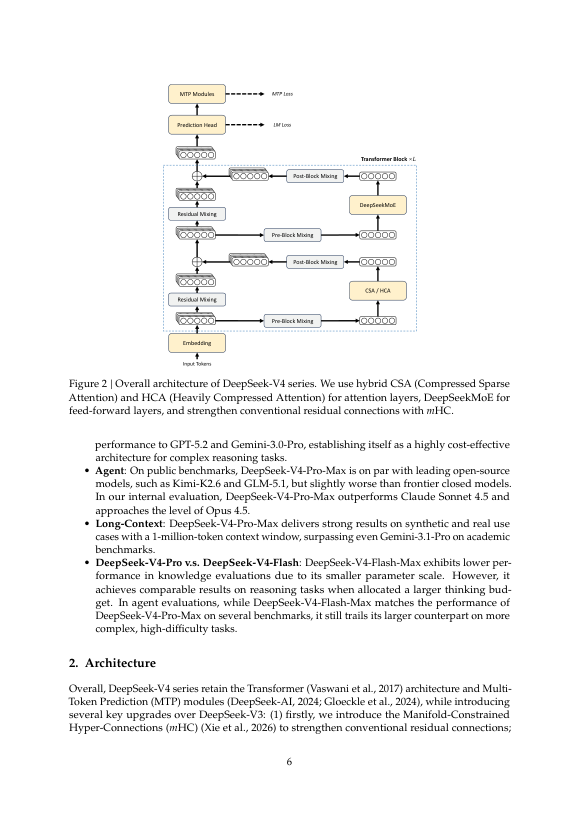

In [13]:
page = pdf[5]
page.get_pixmap(dpi=70).save(PICTURES / "page6.png")

show_image(filename=str(PICTURES / "page6.png"))

Bigger systems go one step further: cut out just the figure, and store its caption as searchable text.
Good to know it exists — we keep things simple here.

## 2.5 Tables

Let's see what a normal text extraction does with a real table (a benchmark table on page 28):

In [14]:
text = pdf[27].get_text()
start = text.find("AGIEval")
print(text[start : start + 130])

AGIEval (EM)
0-shot
80.1
82.6
83.1
MMLU (EM)
5-shot
87.8
88.7
90.1
MMLU-Redux (EM)
5-shot
87.5
89.4
90.8
MMLU-Pro (EM)
5-shot
65.5


The numbers are all there — but **one per line**. The rows and columns are gone, so you can no longer
tell which number belongs to which model. That's why tables need special care.

PyMuPDF has a table finder. Let's try it on the whole paper:

In [15]:
total = 0
for page in pdf:
    total += len(page.find_tables().tables)

print("Tables PyMuPDF found:", total)

fake = pdf[0].find_tables().tables[0]  # the first "table" on page 1
print("First one, page 1, first row:", [str(cell)[:45] for cell in fake.extract()[0]])

Consider using the pymupdf_layout package for a greatly improved page layout analysis.


Tables PyMuPDF found: 45
First one, page 1, first row: ['are available at https://huggingface.co/colle', 'None']


Page 1 is a title page with a chart — and the finder called some chart text a "table". This is the honest
result: the paper's real tables have **no grid lines**, and PyMuPDF's finder looks for drawn lines, so it
found lots of fake tables and missed the real ones.

Two lessons:

1. **Never trust table detection blindly.** Check the result — several rows and columns, mostly filled,
   short cells, some numbers.
2. **If you can't get a clean table, keep the page text** (like step 2.2) instead of throwing it away.
   For serious table extraction, use a layout-aware tool (Docling, `unstructured`) or a cloud service.

## 2.6 Scanned pages (OCR)

A scanned page is just a **picture of a page** — there's no text to extract. To test this for real,
let's make a fake scan: turn page 5 into a picture, and put only that picture on a new page.

In [16]:
original = pdf[4]  # page 5
picture = original.get_pixmap(dpi=150)

scan = pymupdf.open()
scan_page = scan.new_page(width=original.rect.width, height=original.rect.height)
scan_page.insert_image(scan_page.rect, pixmap=picture)

print("Text on the fake scan:", repr(scan_page.get_text()))


def looks_scanned(page):
    return len(page.get_text().strip()) < 40  # almost no text = probably a picture of a page


print("Does it look scanned?", looks_scanned(scan_page))

Text on the fake scan: ''
Does it look scanned? True


No text — so we use **OCR** (optical character recognition): a program that *reads* the picture.
We'll use Tesseract, a free OCR program (installed separately from Python — if it's missing, this cell
just tells you so instead of failing).

In [17]:
import shutil

pytesseract.pytesseract.tesseract_cmd = shutil.which("tesseract") or r"C:\Program Files\Tesseract-OCR\tesseract.exe"

image = Image.frombytes("RGB", (picture.width, picture.height), picture.samples)

try:
    print(pytesseract.image_to_string(image)[:300])
except pytesseract.TesseractNotFoundError:
    print("Tesseract isn't installed, so OCR is skipped. Get it from https://github.com/tesseract-ocr/tesseract")

By employing hybrid CSA and HCA, along with precision optimizations on computation
and storage, DeepSeek-V4 series achieve significantly lower inference FLOPs and a substantially
reduced KV cache size compared with DeepSeek-V3.2, especially in long-context settings. The
right part of Figure 1 demons


It read the page back. OCR is never perfect (equations and odd symbols are hard), so real systems tag
this text as "from OCR" in the metadata, to trust it a little less than normal text.

## 2.7 Broken files must not crash the whole run

Real folders contain corrupted, missing, or wrong files. Wrap each file in `try/except`, so one bad file
is **reported and skipped** — the loop keeps going.

In [18]:
corrupted = Path("data/downloads/corrupted.pdf")
corrupted.write_bytes(b"this is not a real pdf")  # make a bad file on purpose

files = [PDF_PATH, corrupted, Path("data/downloads/missing.pdf")]

for file in files:
    try:
        opened = pymupdf.open(file)
        print("OK     ", file.name, "-", len(opened), "pages")
    except Exception as error:
        print("FAILED ", file.name, "-", type(error).__name__)

OK      deepseek_v4.pdf - 58 pages
FAILED  corrupted.pdf - FileDataError
FAILED  missing.pdf - FileNotFoundError


Three files, one worked, two failed — and the loop finished anyway. **Report, don't crash** is the most
important production habit.

## What we covered

| Real-world case | What we did |
|---|---|
| Need page numbers for citations | One `Document` per page, page in `metadata` |
| Huge PDF metadata | Keep only the fields you need |
| Chunks must still know their page | `split_documents` copies the metadata |
| Charts that aren't pictures | Render the page to an image |
| Tables lose their rows | Don't trust detection blindly; keep the page text |
| Scanned pages | Detect "no text", then OCR |
| Broken files | `try/except` per file, report and continue |

The full picture of a production pipeline is in `notes.md` (Section 3).

## Try it yourself

- Change `chunk_size` in step 2.3 and see how the number of chunks changes.
- Change `pdf[5]` in step 2.4 to another page and render it.
- Point `PDF_URL` at a different arXiv paper (`https://arxiv.org/pdf/<id>`) and re-run everything.
- In step 2.6, change `dpi=150` to `dpi=50` and see how OCR gets worse on a blurrier picture.